In [3]:
import torch 
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from sklearn.metrics import r2_score, mean_squared_error
import mlflow
import mlflow.pytorch
import os


In [4]:
data = pd.read_csv('house_prices.csv')
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,N,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,N,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,N,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,N,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,N,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [5]:
data.shape

(21613, 21)

In [6]:
#Prétraitement des données 

In [7]:
data = data.drop(['id', 'date', 'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_lot15' ], axis=1)


In [8]:
data.shape

(21613, 14)

In [9]:
data.dtypes.value_counts()

int64      9
float64    3
object     2
Name: count, dtype: int64

In [10]:
for col in data.select_dtypes('object'): 
    print(col)

waterfront
condition


In [11]:
#Preprocessing
#Séparartion des données
train_set , test_set = train_test_split(data, test_size = 0.2)

In [12]:
train_set.shape

(17290, 14)

In [13]:
test_set.shape

(4323, 14)

In [14]:
def encodage (data) : 
    cols = ['waterfront', 'condition']
    model = OrdinalEncoder()
    data[cols] = model.fit_transform(data[cols])

    

    return data
    

In [15]:
def preprocessing(data): 
    data = encodage(data)

    X = data.drop(['price'], axis=1)
    y = data['price']

    scaler_x = StandardScaler()
    X = scaler_x.fit_transform(X)

    y_scaler = StandardScaler()
    y = y_scaler.fit_transform(y.values.reshape(-1, 1))
    

    return X, y

In [16]:
x_train, y_train = preprocessing(train_set)

In [17]:
print(f'x: {x_train.shape}, y: {y_train.shape} ')

x: (17290, 13), y: (17290, 1) 


In [18]:
x_test, y_test = preprocessing(test_set)

In [19]:
print(f'x_test: {x_test.shape}, y_test: {y_test.shape} ')

x_test: (4323, 13), y_test: (4323, 1) 


In [20]:
#Convertion en Tensors Pytorch
x_train = torch.FloatTensor(x_train)
y_train = torch.FloatTensor(y_train)
x_test = torch.FloatTensor(x_test)
y_test = torch.FloatTensor(y_test)

In [21]:
print(f'x_train: {x_train.shape}, y_train: {y_train.shape}')

x_train: torch.Size([17290, 13]), y_train: torch.Size([17290, 1])


In [22]:
print(f'x_test: {x_test.shape}, y_test: {y_test.shape}')

x_test: torch.Size([4323, 13]), y_test: torch.Size([4323, 1])


In [23]:
in_features = x_train.shape[1]
class H(nn.Module): 
    def __init__(self, in_features): 
        super(H, self).__init__()
        self.linear1 = nn.Linear(in_features, 16)
        self.dropout1 = nn.Dropout(0.3)
        self.linear2 = nn.Linear(16, 8)
        self.dropout2 = nn.Dropout(0.3)
        self.linear3 = nn.Linear(8, 1)
        #self.dropout3 = nn.Dropout(0.3)
        #self.linear4 = nn.Linear(10, 5)
        #self.dropout4 = nn.Dropout(0.3)
       # self.linear5 = nn.Linear(5, 1)
        

    def forward(self, x):                                                     
        x = F.relu(self.linear1(x)) 
        x = self.dropout1(x)
        x = F.relu(self.linear2(x))
        x = self.dropout2(x)
        #x = F.relu(self.linear3(x))
        #x = self.dropout3(x)
        #x = F.relu(self.linear4(x))
        #x = self.dropout4(x)
        x = self.linear3(x)

        return x 
model = H(in_features)
        
    

In [24]:
logloss = nn.MSELoss()

In [25]:
optimize = optim.Adam(model.parameters())

C:\Users\Nathalie\anaconda3\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


  0%|          | 0/5000 [00:00<?, ?it/s]

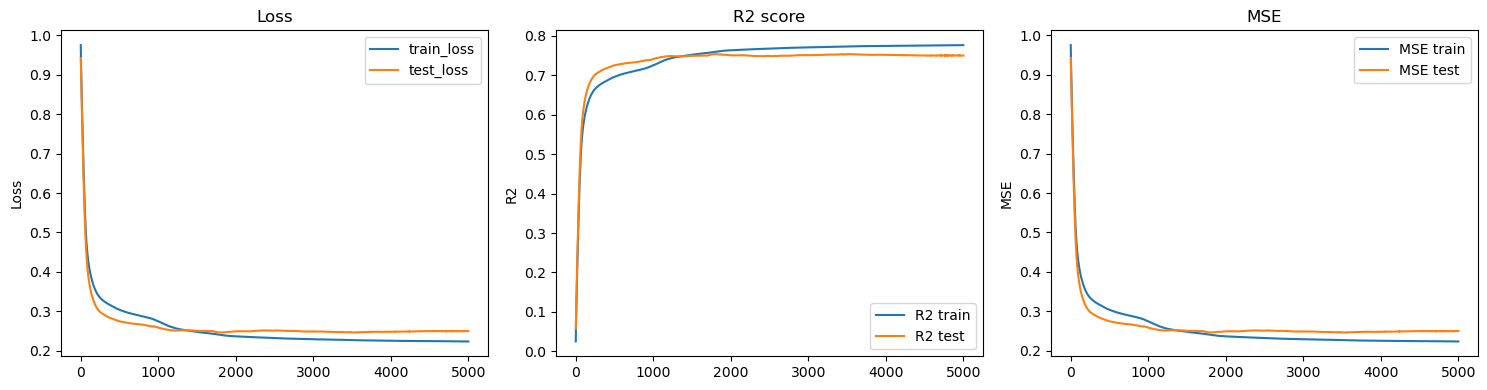

2026/03/27 23:37:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/27 23:37:14 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Expérience enregistré dans mlflow


In [26]:
n_iters = 5000 

#Démarrer une expérience mlflow 
mlflow.set_tracking_uri("file:///C:/Users/Nathalie/jupiter_notebook/mlruns")
mlflow.set_experiment('house_prices_prédiction')

with mlflow.start_run(): 
    mlflow.log_param('n_iters', n_iters)
    mlflow.log_param('optimizer', 'Adam')

    losses_train = []
    losses_test = []
    r2_train_list = []
    r2_test_list = []
    mse_train_list = []
    mse_test_list = []
    
    best_loss = float('inf')
    patience = 50
    counter = 0
    
    for i in tqdm(range(n_iters)):
       
        optimize.zero_grad()
        
        # Forward pass
        y_pred_train_tensor = model(x_train)  # tensor
        loss_train = logloss(y_pred_train_tensor, y_train)  # loss sur train
        
        # Backward et update
        loss_train.backward()
        optimize.step()
        
        # Stockage du loss
        losses_train.append(loss_train.item())
    
        #test 
        model.eval()
        with torch.no_grad():
            y_pred_test_tensor = model(x_test)
            loss_test = logloss(y_pred_test_tensor, y_test)
     
        losses_test.append(loss_test.item())
        
        
        # Convertir en numpy pour sklearn
        y_pred_train_np = y_pred_train_tensor.detach().numpy()
        y_pred_test_np = y_pred_test_tensor.detach().numpy()
        y_train_np = y_train.detach().numpy()
        y_test_np = y_test.detach().numpy()
        
        # Calcul des métriques
        r2_train = r2_score(y_train_np, y_pred_train_np)
        r2_test  = r2_score(y_test_np, y_pred_test_np)
        mse_train = mean_squared_error(y_train_np, y_pred_train_np)
        mse_test = mean_squared_error(y_test_np, y_pred_test_np)

        r2_train_list.append(r2_train)
        r2_test_list.append(r2_test)
        mse_train_list.append(mse_train)
        mse_test_list.append(mse_test)

    #Enregistrement des metrics 
    mlflow.log_metric('train loss', loss_train.item())
    mlflow.log_metric('test loss', loss_test.item())
    mlflow.log_metric('r2_train', r2_train)
    mlflow.log_metric('r2_test', r2_test)
    mlflow.log_metric('mse_train', mse_train)
    mlflow.log_metric('mse_test', mse_test)
    

    # --- Tracé des figures ---
    plt.figure(figsize=(15,4))
    
    plt.subplot(1,3,1)
    plt.plot(losses_train, label ='train_loss')
    plt.plot(losses_test, label='test_loss')
    plt.title("Loss")
    plt.legend()
    
    plt.ylabel("Loss")
    
    plt.subplot(1,3,2)
    plt.plot(r2_train_list, label="R2 train")
    plt.plot(r2_test_list, label="R2 test")
    plt.title("R2 score")
    
    plt.ylabel("R2")
    plt.legend()
    
    plt.subplot(1,3,3)
    plt.plot(mse_train_list, label="MSE train")
    plt.plot(mse_test_list, label="MSE test")
    plt.title("MSE")

    plt.ylabel("MSE")
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('house_price.png')
    mlflow.log_artifact("house_price.png")
    plt.show()
   
    plt.close()

    #mlflow
    
    mlflow.pytorch.log_model(model, 'model')

    print("Expérience enregistré dans mlflow")
    
